In [1]:
import pandas as pd

ndvi = pd.read_csv(r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\processed\Saptari_Block_S2_NDVI.csv")
rain = pd.read_csv(r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\processed\Saptari_Block_Rainfall.csv")
et   = pd.read_csv(r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\processed\Saptari_Block_ET.csv")

print(ndvi.shape, rain.shape, et.shape)


(85800, 8) (13860, 8) (37785, 8)


In [2]:
print(et.head(2))

   system:index    GaPa_NaPa  OBJECTID  block_id      mean  month  year  \
0  2021_01_01_0      Surunga      4341         0  4.989154      1  2021   
1  2021_01_01_1  Dakneshwori      4342         1  4.880667      1  2021   

                                                .geo  
0  {"type":"Polygon","coordinates":[[[86.53453389...  
1  {"type":"Polygon","coordinates":[[[86.63108026...  


In [3]:
ndvi = ndvi.rename(columns={"mean": "NDVI"})
rain = rain.rename(columns={"mean": "Rainfall"})
et   = et.rename(columns={"mean": "ET"})

ndvi = ndvi[["block_id", "year", "month", "NDVI"]]
rain = rain[["block_id", "year", "month", "Rainfall"]]
et   = et[["block_id", "year", "month", "ET"]]


In [4]:
lookup = (
    ndvi[["block_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

lookup["block_uid"] = lookup.index

lookup.head()


,block_id,block_uid
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


In [5]:
ndvi = ndvi.merge(lookup, on="block_id", how="left")
rain = rain.merge(lookup, on="block_id", how="left")
et   = et.merge(lookup,   on="block_id", how="left")


In [6]:
ndvi_monthly = (
    ndvi
    .groupby(["block_uid", "year", "month"], as_index=False)
    .agg(NDVI=("NDVI", "mean"))
)

et_monthly = (
    et
    .groupby(["block_uid", "year", "month"], as_index=False)
    .agg(ET=("ET", "mean"))
)

df = (
    ndvi_monthly
    .merge(rain[["block_uid", "year", "month", "Rainfall"]],
           on=["block_uid", "year", "month"], how="left")
    .merge(et_monthly,
           on=["block_uid", "year", "month"], how="left")
)

df.head()


,block_uid,year,month,NDVI,Rainfall,ET
0,0,2019,1,0.181885,9.056077,NaN
1,0,2019,2,0.310921,37.808368,NaN
2,0,2019,3,0.262275,21.742298,NaN
3,0,2019,4,0.276732,56.624119,NaN
4,0,2019,5,0.292411,79.037429,NaN


In [7]:
et.groupby("year").size()


year
2021    7590
2022    7425
2023    7590
2024    7590
2025    7590
dtype: int64

In [8]:
df = df[df["year"] >= 2021].reset_index(drop=True)


In [9]:
df.isna().sum()


block_uid    0
year         0
month        0
NDVI         0
Rainfall     0
ET           0
dtype: int64

In [10]:
df = df.sort_values(["block_uid", "year", "month"]).reset_index(drop=True)


In [11]:
df["rain_1m"] = df["Rainfall"]


In [12]:
df["rain_3m"] = (
    df.groupby("block_uid")["Rainfall"]
      .rolling(3)
      .sum()
      .reset_index(0, drop=True)
)


In [13]:
df["rain_6m"] = (
    df.groupby("block_uid")["Rainfall"]
      .rolling(6)
      .sum()
      .reset_index(0, drop=True)
)


In [14]:
df["rain_anomaly"] = (
    df["Rainfall"]
    - df.groupby(["block_uid", "month"])["Rainfall"].transform("mean")
)


In [15]:
df["ndvi_change"] = (
    df.groupby("block_uid")["NDVI"]
      .diff()
)


In [16]:
df["ndvi_anomaly"] = (
    df["NDVI"]
    - df.groupby(["block_uid", "month"])["NDVI"].transform("mean")
)


In [17]:
df["water_surplus"] = df["Rainfall"] - df["ET"]


In [19]:
df["flood_pressure"] = (
    0.4 * df["rain_3m"] +
    0.3 * df["rain_anomaly"] +
    0.2 * df["water_surplus"] -
    0.1 * df["ndvi_anomaly"]
)


In [20]:
df = df.dropna().reset_index(drop=True)


In [21]:
df.head()



,block_uid,year,month,NDVI,Rainfall,ET,rain_1m,rain_3m,rain_6m,rain_anomaly,ndvi_change,ndvi_anomaly,water_surplus,flood_pressure
0,0,2021,6,0.261311,395.183481,19.214038,395.183481,773.836964,801.757671,81.441289,-0.075515,0.033434,375.969442,409.157717
1,0,2021,9,0.505417,190.518036,27.211838,190.518036,934.629612,984.958595,-64.233157,0.244106,0.057743,163.306199,387.237363
2,0,2021,10,0.460848,101.212279,21.554939,101.212279,686.913796,1078.857208,1.871281,-0.044568,0.079493,79.657340,291.250421
3,0,2021,11,0.276445,5.447090,14.340980,5.447090,297.177405,1071.014370,2.681224,-0.184403,0.007932,-8.893890,117.895758
4,0,2021,12,0.217789,18.567932,7.499973,18.567932,125.227301,1059.856913,9.454287,-0.058656,0.003413,11.067959,55.140457


In [22]:
df = df.sort_values(["block_uid", "year", "month"]).reset_index(drop=True)


In [23]:
df["et_rain_ratio"] = df["ET"] / (df["Rainfall"] + 1e-3)


In [24]:
df["recharge_deficit"] = df["Rainfall"] - df["ET"]


In [25]:
df["et_3m"] = (
    df.groupby("block_uid")["ET"]
      .rolling(3)
      .mean()
      .reset_index(0, drop=True)
)


In [26]:
df["recharge_deficit_6m"] = (
    df.groupby("block_uid")["recharge_deficit"]
      .rolling(6)
      .sum()
      .reset_index(0, drop=True)
)


In [27]:
df["ndvi_et_ratio"] = df["NDVI"] / (df["ET"] + 1e-3)


In [28]:
df["ndvi_anomaly"] = (
    df["NDVI"]
    - df.groupby(["block_uid", "month"])["NDVI"].transform("mean")
)


In [29]:
df["gw_stress_index"] = (
    0.35 * df["et_rain_ratio"] +
    0.30 * (-df["recharge_deficit"]) +
    0.20 * df["et_3m"] -
    0.15 * df["ndvi_anomaly"]
)


In [30]:
df = df.dropna().reset_index(drop=True)


In [31]:
flood_features = [
    "rain_1m",
    "rain_3m",
    "rain_6m",
    "rain_anomaly",
    "ndvi_change",
    "ndvi_anomaly",
    "water_surplus"
]


In [32]:
gw_features = [
    "et_rain_ratio",
    "recharge_deficit",
    "et_3m",
    "recharge_deficit_6m",
    "ndvi_et_ratio",
    "ndvi_anomaly"
]


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [34]:
target_flood = "flood_pressure"
Xf = df[flood_features]
yf = df[target_flood]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.2, random_state=42
)

flood_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

flood_model.fit(Xf_train, yf_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [35]:
# --- TRAIN GROUNDWATER MODEL ---

# 1. Define Target for Groundwater
target_gw = "gw_stress_index"

# 2. Select Features and Target
Xg = df[gw_features]
yg = df[target_gw]

# 3. Split Data (80% Train, 20% Test)
# We use the same random_state=42 for reproducibility
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42
)

# 4. Train Random Forest Regressor
gw_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

gw_model.fit(Xg_train, yg_train)
print("✅ Groundwater model trained successfully!")

✅ Groundwater model trained successfully!


In [36]:
df[target_flood].describe()


count    7095.000000
mean      164.814445
std       166.237868
min         1.541730
25%        27.605341
50%       100.844645
75%       305.115675
max       653.668339
Name: flood_pressure, dtype: float64

In [37]:
df[target_gw].describe()

count    7095.000000
mean      223.908701
std       786.010336
min      -189.262657
25%       -56.681874
50%        -9.795475
75%         0.951797
max      6645.049070
Name: gw_stress_index, dtype: float64

In [38]:
import numpy as np

# 1. Create a Log-Transformed Ratio (Stabilizes huge values)
df["log_et_rain_ratio"] = np.log1p(df["et_rain_ratio"])

# 2. Recalculate Groundwater Stress Index with the Log Ratio
df["gw_stress_index"] = (
    0.35 * df["log_et_rain_ratio"] +      # Uses Log scale now (0 to ~10 range)
    0.30 * (-df["recharge_deficit"]) +    # Keeps physical units (mm)
    0.20 * df["et_3m"] -                  # Keeps physical units (mm)
    0.15 * df["ndvi_anomaly"]             # Small unitless value
)

# 3. Check the new stats
print("New GW Stress Stats:")
print(df["gw_stress_index"].describe())


New GW Stress Stats:
count    7095.000000
mean      -30.398718
std        42.958734
min      -189.262693
25%       -56.681999
50%        -9.795677
75%         0.882010
max        14.421879
Name: gw_stress_index, dtype: float64


In [ ]:
# !pip install shap

In [40]:
import shap
print(shap.__version__)
shap.initjs()


0.52.0


Background dataset has 5676 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5676 when initializing the masker.
 96%|=================== | 1360/1419 [00:21<00:00]       

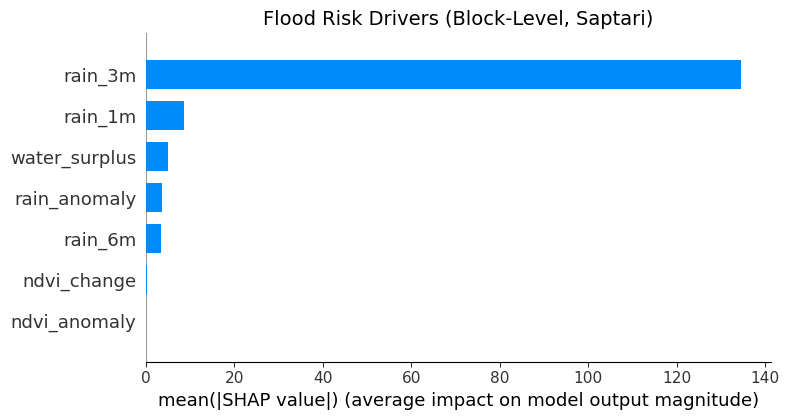

In [41]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

explainer_flood = shap.Explainer(flood_model, Xf_train)
shap_values_flood = explainer_flood(Xf_test)

# SHAP bar plot with title
shap.summary_plot(
    shap_values_flood.values,
    Xf_test,
    plot_type="bar",
    show=False
)

plt.title("Flood Risk Drivers (Block-Level, Saptari)", fontsize=14)
plt.tight_layout()
plt.savefig("flood_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()


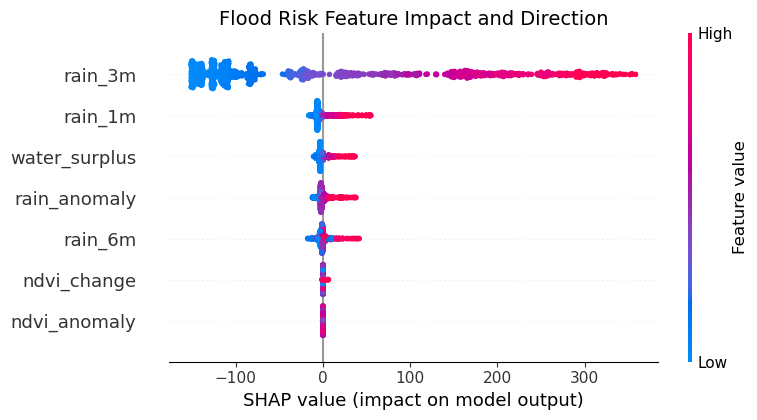

In [42]:
shap.summary_plot(
    shap_values_flood.values,
    Xf_test,
    show=False
)
plt.title("Flood Risk Feature Impact and Direction", fontsize=14)
plt.tight_layout()
plt.savefig("Flood Risk Feature Impact and Direction.png", dpi=300, bbox_inches="tight")
plt.show()


✅ Saved critical plot to: outputs/flood_waterfall_critical_testset.png


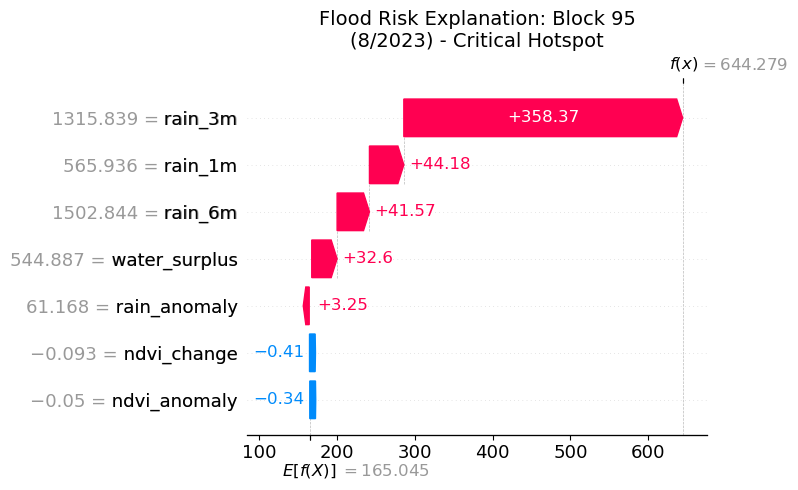

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)

# 1. Find the position of the highest risk row IN THE TEST SET
# We use the model predictions on Xf_test to find the worst case
test_predictions = flood_model.predict(Xf_test)
max_risk_pos = np.argmax(test_predictions)  # This gives a position like 142 (0 to 3946)

# 2. Get the corresponding original index from the main dataframe
# This allows us to look up the Block Name and Date
original_idx = Xf_test.index[max_risk_pos]

# 3. Generate the Waterfall Plot using the position
shap.plots.waterfall(
    shap_values_flood[max_risk_pos],
    show=False
)

# 4. Create the Dynamic Title using the original index
block_name = df.loc[original_idx, "block_name"] if "block_name" in df.columns else f"Block {df.loc[original_idx, 'block_uid']}"
date_label = f"{int(df.loc[original_idx, 'month'])}/{int(df.loc[original_idx, 'year'])}"

plt.title(
    f"Flood Risk Explanation: {block_name}\n({date_label}) - Critical Hotspot",
    fontsize=14
)

plt.tight_layout()

# 5. Save and Show
save_path = f"outputs/flood_waterfall_critical_testset.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✅ Saved critical plot to: {save_path}")
plt.show()

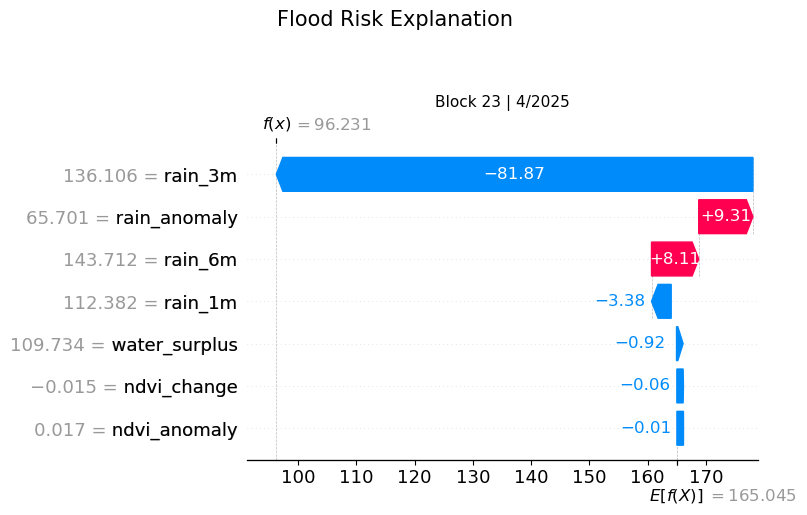

In [44]:
import matplotlib.pyplot as plt
import os

# 1. Setup
os.makedirs("outputs", exist_ok=True)
idx = 0  # Index inside the TEST set (0 to ~3900)

# 2. Get the correct corresponding row from the main DataFrame
# Xf_test.index contains the original indices from df
original_row_idx = Xf_test.index[idx]
row_data = df.loc[original_row_idx]

# 3. Generate Plot
shap.plots.waterfall(shap_values_flood[idx], show=False)

# 4. Add Titles using the CORRECT matched data
plt.suptitle(
    "Flood Risk Explanation",
    fontsize=15,
    y=1.02
)

plt.title(
    f"Block {int(row_data['block_uid'])} | "
    f"{int(row_data['month'])}/{int(row_data['year'])}",
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# 5. Save
plt.savefig(
    f"outputs/flood_waterfall_block_{int(row_data['block_uid'])}_"
    f"{int(row_data['year'])}_{int(row_data['month'])}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

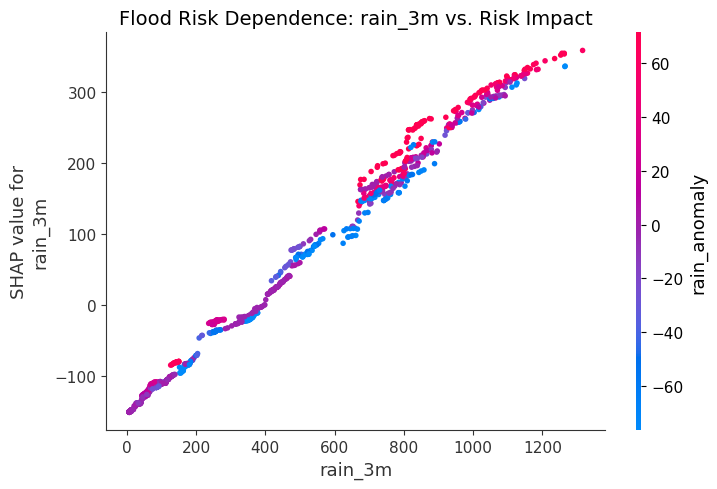

In [45]:
import matplotlib.pyplot as plt

# Choose your top feature (e.g., 3-month cumulative rainfall)
feature = "rain_3m"

# Generate Dependence Plot
# interaction_index="rain_anomaly" colors the dots by a second feature to show complex relationships
shap.dependence_plot(
    feature,
    shap_values_flood.values,
    Xf_test,
    interaction_index="rain_anomaly",
    show=False
)

# Add Title and Save
plt.title(f"Flood Risk Dependence: {feature} vs. Risk Impact", fontsize=14)
plt.tight_layout()

# Save the figure
plt.savefig(f"outputs/flood_dependence_{feature}.png", dpi=300, bbox_inches="tight")
plt.show()

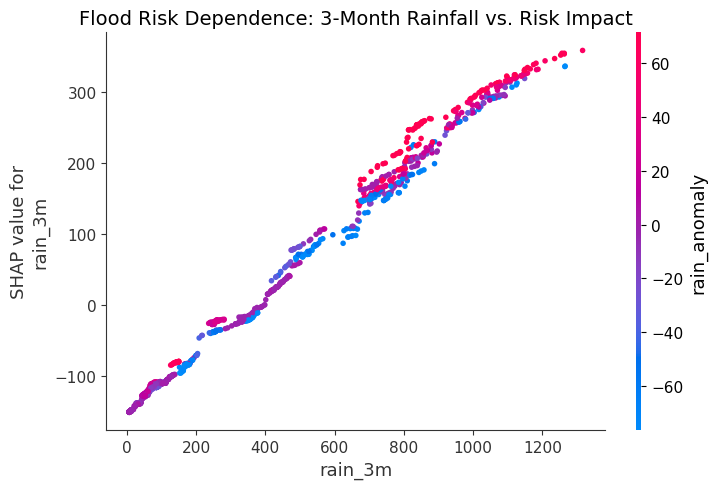

In [46]:
import matplotlib.pyplot as plt

# Generate Dependence Plot
# show=False allows us to add a title and save the plot
shap.dependence_plot(
    "rain_3m",
    shap_values_flood.values,
    Xf_test,
    interaction_index="rain_anomaly",
    show=False
)

# Add Title and Adjust Layout
plt.title("Flood Risk Dependence: 3-Month Rainfall vs. Risk Impact", fontsize=14)
plt.tight_layout()

# Save the figure
plt.savefig("outputs/flood_dependence_rain_3m.png", dpi=300, bbox_inches="tight")

# Display
plt.show()

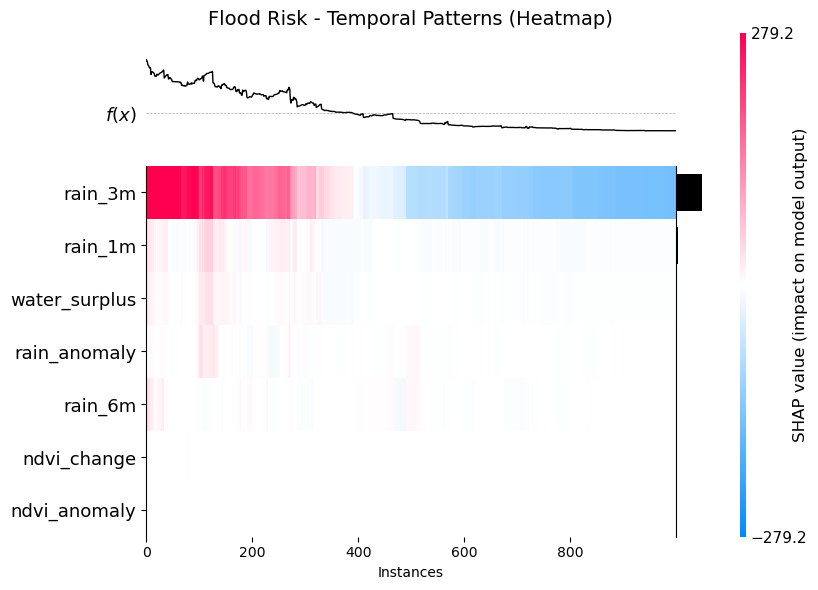

In [47]:
# Corrected SHAP Heatmap Code
import shap
import matplotlib.pyplot as plt

# We take the first 1,000 samples ([:1000]) to make it run fast
shap.plots.heatmap(
    shap_values_flood[:1000],  
    max_display=10,
    show=False
)

plt.title("Flood Risk - Temporal Patterns (Heatmap)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/flood_shap_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
import shap
import matplotlib.pyplot as plt

# 1. Generate the Interactive Force Plot
# This creates a JavaScript-based visualization
plot_html = shap.force_plot(
    explainer_flood.expected_value,
    shap_values_flood.values[0],
    Xf_test.iloc[0],
    show=False  # Keep False so we can save it
)

# 2. Save as HTML (Best for Web Apps / Dashboards)
# You can open this file in any browser
shap.save_html("outputs/flood_force_plot_interactive.html", plot_html)

print("✅ Saved interactive plot to: outputs/flood_force_plot_interactive.html")

# 3. (Optional) Static Version for Reports (Matplotlib)
# If you need a PNG image for a PDF/PPT
plt.figure(figsize=(20, 3))
shap.force_plot(
    explainer_flood.expected_value,
    shap_values_flood.values[0],
    Xf_test.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("outputs/flood_force_plot_static.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Saved static image to: outputs/flood_force_plot_static.png")

✅ Saved interactive plot to: outputs/flood_force_plot_interactive.html
✅ Saved static image to: outputs/flood_force_plot_static.png


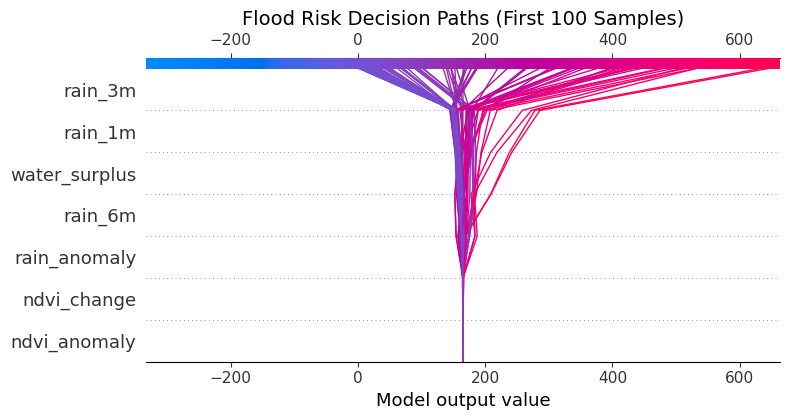

In [49]:
import shap
import matplotlib.pyplot as plt

# Generate Decision Plot for the first 100 samples
# show=False allows us to add a title and save
shap.decision_plot(
    explainer_flood.expected_value,
    shap_values_flood.values[:100],
    Xf_test.iloc[:100],
    show=False
)

# Add Title and Save
plt.title("Flood Risk Decision Paths (First 100 Samples)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/flood_decision_plot.png", dpi=300, bbox_inches="tight")
plt.show()

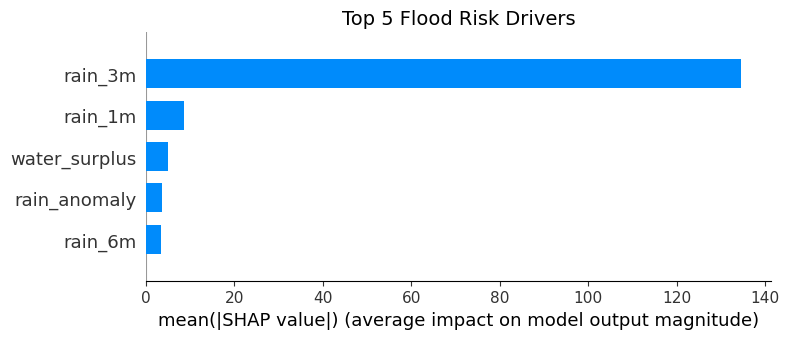

In [50]:
import shap
import matplotlib.pyplot as plt

# Generate the Top-5 Bar Plot
shap.summary_plot(
    shap_values_flood.values,
    Xf_test,
    plot_type="bar",
    max_display=5,
    show=False
)

# Add Title and Save
plt.title("Top 5 Flood Risk Drivers", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/flood_shap_top5_bar.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
import numpy as np

df["log_et_rain_ratio"] = np.log1p(df["et_rain_ratio"])


In [52]:
df[["et_rain_ratio", "log_et_rain_ratio"]].describe()


,et_rain_ratio,log_et_rain_ratio
count,7095.000000,7095.000000
mean,727.826373,1.233746
std,2208.521370,2.724800
min,0.009699,0.009652
25%,0.047946,0.046832
50%,0.135584,0.127147
75%,0.698671,0.529846
max,18954.498967,9.849849


In [53]:
# 1. Recalculate the Groundwater Stress Index using the NEW log feature
# We replace 'et_rain_ratio' with 'log_et_rain_ratio' in the formula
df["gw_stress_index"] = (
    0.35 * df["log_et_rain_ratio"] +
    0.30 * (-df["recharge_deficit"]) +
    0.20 * df["et_3m"] -
    0.15 * df["ndvi_anomaly"]
)

# Check if the new Target Variable is reasonable (should be much smaller than before)
print("New Target Stats:")
print(df["gw_stress_index"].describe())

# 2. Update Feature List for Groundwater Model
# We must use the log version here too
gw_features = [
    "log_et_rain_ratio",       # <--- Use the stabilized feature
    "recharge_deficit",
    "et_3m",
    "recharge_deficit_6m",
    "ndvi_et_ratio",
    "ndvi_anomaly"
]

target_gw = "gw_stress_index"

# 3. Prepare Data for Training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Xg = df[gw_features]
yg = df[target_gw]

# Split (80% Train, 20% Test)
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42
)

# 4. Train the Groundwater Model
gw_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

gw_model.fit(Xg_train, yg_train)
print("✅ Groundwater model trained successfully!")

New Target Stats:
count    7095.000000
mean      -30.398718
std        42.958734
min      -189.262693
25%       -56.681999
50%        -9.795677
75%         0.882010
max        14.421879
Name: gw_stress_index, dtype: float64
✅ Groundwater model trained successfully!


In [54]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the Log-Transformed Ratio
# This converts a ratio of 6509 into ~8.7, which is much safer
df["log_et_rain_ratio"] = np.log1p(df["et_rain_ratio"])

# 2. Recalculate the Groundwater Stress Index using the LOG ratio
df["gw_stress_index"] = (
    0.35 * df["log_et_rain_ratio"] +      # Use the LOG version here
    0.30 * (-df["recharge_deficit"]) +
    0.20 * df["et_3m"] -
    0.15 * df["ndvi_anomaly"]
)

# 3. Check the stats again
print("Stabilized Stats:")
print(df["gw_stress_index"].describe())



Stabilized Stats:
count    7095.000000
mean      -30.398718
std        42.958734
min      -189.262693
25%       -56.681999
50%        -9.795677
75%         0.882010
max        14.421879
Name: gw_stress_index, dtype: float64


Background dataset has 5676 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5676 when initializing the masker.
 96%|=================== | 1359/1419 [00:16<00:00]       

✅ Groundwater SHAP values calculated.


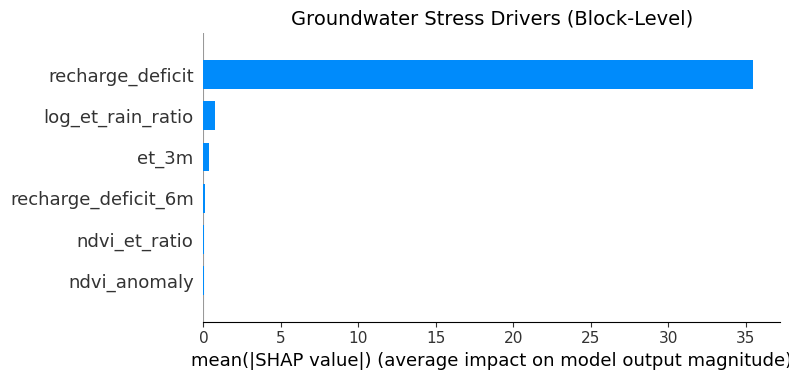

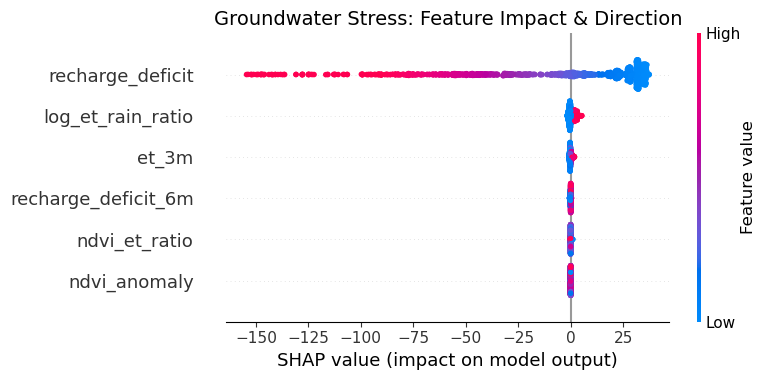

In [55]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize Explainer for Groundwater Model
# We use the TreeExplainer since it's a Random Forest
explainer_gw = shap.Explainer(gw_model, Xg_train)
shap_values_gw = explainer_gw(Xg_test)

print("✅ Groundwater SHAP values calculated.")

# 2. Generate Global Importance Bar Plot
# This shows WHICH features matter most
plt.figure()
shap.summary_plot(
    shap_values_gw.values,
    Xg_test,
    plot_type="bar",
    max_display=6,
    show=False
)
plt.title("Groundwater Stress Drivers (Block-Level)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/gw_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Generate Beeswarm Plot (Impact & Direction)
# This shows HOW they matter (e.g., High ET/Rain Ratio -> High Stress)
plt.figure()
shap.summary_plot(
    shap_values_gw.values,
    Xg_test,
    show=False
)
plt.title("Groundwater Stress: Feature Impact & Direction", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/gw_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
import geopandas as gpd

# geo_json_string = r'../data/boundaries/blocks_saptari_gee.geojson'
# df = gpd.read_file(geo_json_string)
# 1. Load the GEE-exported GeoJSON (The one with the correct IDs)
# We use r"..." to handle the backslashes in your Windows path
block_gdf = gpd.read_file(r'S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\blocks_saptari_gee.geojson')

# 2. Check the columns to confirm 'block_id' exists
print("Columns in block_gdf:", block_gdf.columns)

# 3. Ensure block_id is an Integer (Crucial for merging)
# GEE sometimes exports IDs as strings, so we force it to int
block_gdf["block_id"] = block_gdf["block_id"].astype(int)

# 4. Ensure your Dataframe also uses int for the join key
# Note: In your df, the column is named 'block_uid'. We will use that.
df["block_uid"] = df["block_uid"].astype(int)

print("✅ IDs aligned. Ready to merge.")

Columns in block_gdf: Index(['block_id', 'OBJECTID', 'GaPa_NaPa', 'geometry'], dtype='object')
✅ IDs aligned. Ready to merge.


In [57]:
# 1. Aggregate Groundwater Metrics to Block Level
# We group by 'block_uid' to get one row per block
gw_map_df = (
    df.groupby("block_uid", as_index=False)
      .agg({
          "gw_stress_index": "mean",
          "log_et_rain_ratio": "mean"
      })
)

# 2. Rename for clarity (Match the GeoDataFrame column)
gw_map_df = gw_map_df.rename(columns={"block_uid": "block_id"})

# 3. Merge into the GeoDataFrame
# This is the step that was failing before. Now it will work.
block_gdf = block_gdf.merge(
    gw_map_df,
    on="block_id",
    how="left"
)

# 4. Verify the merge
# Count how many rows are NOT empty. It should be > 0.90 (90%+)
valid_ratio = 1 - block_gdf["gw_stress_index"].isna().mean()
print(f"✅ Merge Success! {valid_ratio:.1%} of blocks have valid data.")

✅ Merge Success! 100.0% of blocks have valid data.


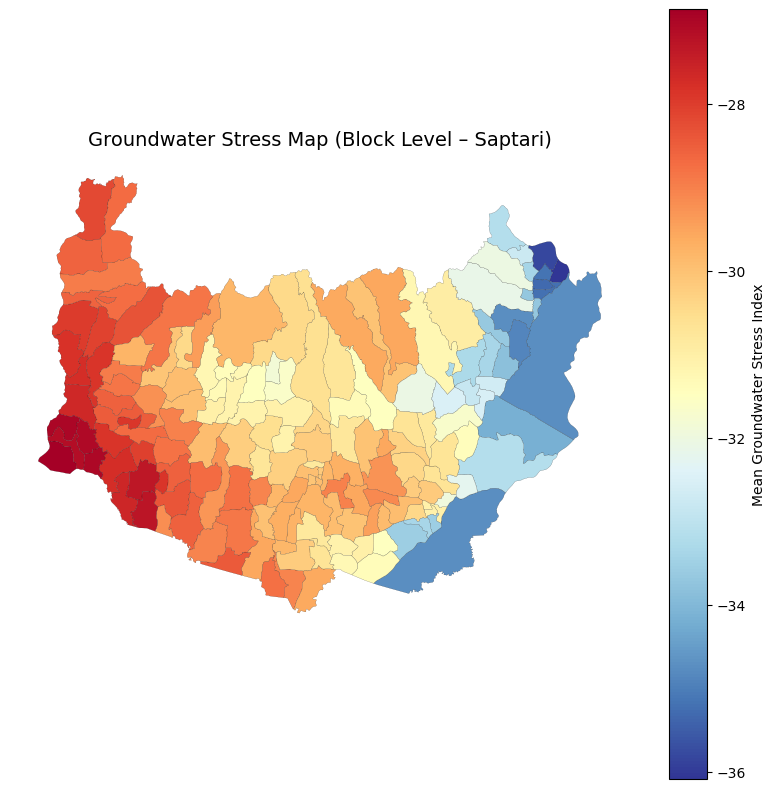

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

block_gdf.plot(
    column="gw_stress_index",
    cmap="RdYlBu_r",  # Red = High Stress, Blue = Low Stress
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    legend_kwds={'label': "Mean Groundwater Stress Index"},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Groundwater Stress Map (Block Level – Saptari)", fontsize=14)
ax.axis("off")
plt.show()

In [59]:
df.columns

Index(['block_uid', 'year', 'month', 'NDVI', 'Rainfall', 'ET', 'rain_1m',
       'rain_3m', 'rain_6m', 'rain_anomaly', 'ndvi_change', 'ndvi_anomaly',
       'water_surplus', 'flood_pressure', 'et_rain_ratio', 'recharge_deficit',
       'et_3m', 'recharge_deficit_6m', 'ndvi_et_ratio', 'gw_stress_index',
       'log_et_rain_ratio'],
      dtype='object')

In [61]:

# 1. Aggregate Flood Pressure (Monthly -> Block Level)
flood_block = (
    df.groupby("block_uid", as_index=False)
      .agg(
          flood_pressure=("flood_pressure", "mean"),
          rain_3m=("rain_3m", "mean"),
          water_surplus=("water_surplus", "mean")
      )
)

# 2. Define Flood Risk Classes (Quantile-based)
# We use quantiles because 'flood_pressure' is an index, not a physical unit
q40 = flood_block["flood_pressure"].quantile(0.40)
q70 = flood_block["flood_pressure"].quantile(0.70)
q90 = flood_block["flood_pressure"].quantile(0.90)

def classify_flood_risk(val):
    if val <= q40:
        return "Low"
    elif val <= q70:
        return "Moderate"
    elif val <= q90:
        return "High"
    else:
        return "Severe"

flood_block["flood_risk_class"] = flood_block["flood_pressure"].apply(classify_flood_risk)

# 3. Merge with GeoDataFrame (Spatial Join)
# Ensure ID types match
block_gdf["block_id"] = block_gdf["block_id"].astype(int)
flood_block["block_uid"] = flood_block["block_uid"].astype(int)

block_gdf = block_gdf.merge(
    flood_block,
    left_on="block_id",
    right_on="block_uid",
    how="left"
)



In [62]:
block_gdf.head(5)

,block_id,OBJECTID,GaPa_NaPa,geometry,gw_stress_index,log_et_rain_ratio,block_uid_x,flood_pressure_x,rain_3m_x,water_surplus_x,flood_risk_class_x,block_uid_y,flood_pressure_y,rain_3m_y,water_surplus_y,flood_risk_class_y
0,0,4341,Surunga,"POLYGON ((453671.231 2946370.985, 453686.356 2...",-27.737391,0.659783,0,148.227961,324.021169,99.110163,Low,0,148.227961,324.021169,99.110163,Low
1,1,4342,Dakneshwori,"POLYGON ((463246.049 2934288.208, 463254.109 2...",-28.352568,1.185834,1,152.540513,333.891679,102.033519,Low,1,152.540513,333.891679,102.033519,Low
2,2,4343,Dakneshwori,"POLYGON ((468868.839 2939991.04, 468914.676 29...",-30.233993,1.162162,2,161.204214,351.503459,108.128856,Low,2,161.204214,351.503459,108.128856,Low
3,3,4344,Belhi Chapena,"POLYGON ((469313.301 2932125.406, 469319.458 2...",-29.536598,1.214652,3,163.700041,358.860779,107.755745,Moderate,3,163.700041,358.860779,107.755745,Moderate
4,4,4345,Rajbiraj,"POLYGON ((477973.98 2935513.956, 478056.124 29...",-28.999216,1.403511,4,159.733785,349.049779,105.472691,Low,4,159.733785,349.049779,105.472691,Low


In [63]:
# 4. Verify Merge
print("Flood data merged.")
print(block_gdf[["GaPa_NaPa", "flood_pressure_x", "flood_risk_class_x"]].head())

Flood data merged.
       GaPa_NaPa  flood_pressure_x flood_risk_class_x
0        Surunga        148.227961                Low
1    Dakneshwori        152.540513                Low
2    Dakneshwori        161.204214                Low
3  Belhi Chapena        163.700041           Moderate
4       Rajbiraj        159.733785                Low


C:\Users\sujan\AppData\Local\Temp\ipykernel_28064\210826037.py:13: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  block_gdf.plot(


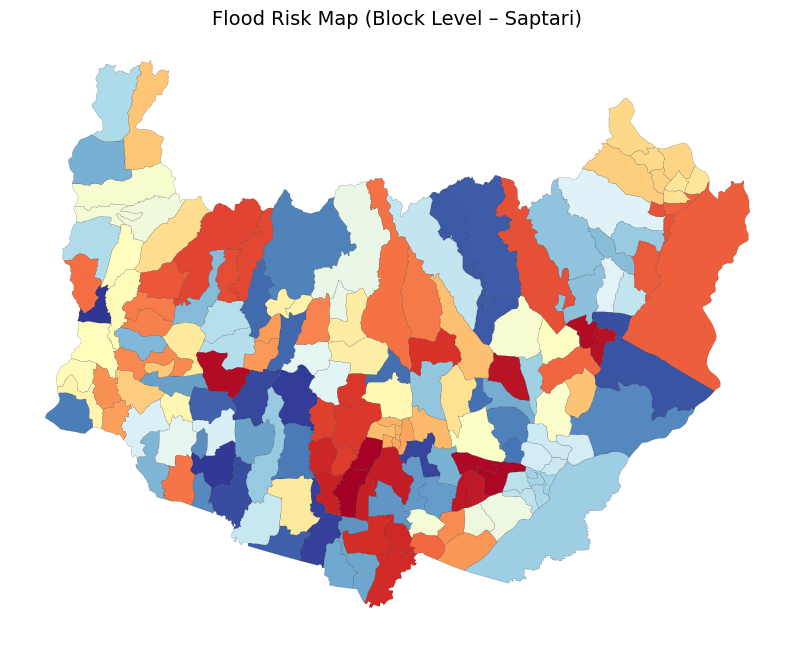

In [64]:

import matplotlib.pyplot as plt

# Define distinct colors for Flood Risk
flood_colors = {
    "Low": "#eff3ff",      # Very light blue
    "Moderate": "#9ecae1", # Light blue
    "High": "#3182bd",     # Medium blue
    "Severe": "#08519c"    # Dark blue
}

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

block_gdf.plot(
    column="flood_risk_class_x",
    categorical=True,
    legend=True,
    legend_kwds={'label': "Flood Risk"},
    cmap="RdYlBu_r",  # Red = High Stress, Blue = Low Stress
    color=block_gdf["flood_risk_class_x"].map(flood_colors).fillna("lightgrey"),
    linewidth=0.1,
    edgecolor="black",
    ax=ax
)

ax.set_title("Flood Risk Map (Block Level – Saptari)", fontsize=14)
ax.axis("off")

# Save the map
plt.savefig("outputs/flood_risk_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [65]:
# 1. Aggregate both risks to the block level (getting the "chronic" risk)
risk_summary = (
    df.groupby("block_uid", as_index=False)
      .agg({
          "flood_pressure": "mean",       # Chronic flood risk
          "gw_stress_index": "mean"       # Chronic groundwater stress
      })
)

# 2. Normalize to 0-1 scale (Min-Max Scaling)
# This ensures one risk doesn't dominate the other just because the numbers are bigger
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

risk_summary["flood_norm"] = normalize(risk_summary["flood_pressure"])
risk_summary["gw_norm"] = normalize(risk_summary["gw_stress_index"])

# 3. Calculate Compound Risk Index (Weighted Average)
# You can adjust weights. 0.5/0.5 assumes both problems are equally critical.
w_flood = 0.5
w_gw = 0.5

risk_summary["compound_risk"] = (
    w_flood * risk_summary["flood_norm"] +
    w_gw * risk_summary["gw_norm"]
)

# 4. Define Risk Classes (Quantile-based)
# "Critical" = Top 20% most vulnerable blocks
q80 = risk_summary["compound_risk"].quantile(0.80)
q60 = risk_summary["compound_risk"].quantile(0.60)
q40 = risk_summary["compound_risk"].quantile(0.40)

def classify_compound(x):
    if x > q80: return "Critical"
    elif x > q60: return "High"
    elif x > q40: return "Moderate"
    else: return "Low"

risk_summary["compound_class"] = risk_summary["compound_risk"].apply(classify_compound)

# Check the distribution
print(risk_summary["compound_class"].value_counts())

compound_class
Low         66
Critical    33
High        33
Moderate    33
Name: count, dtype: int64


C:\Users\sujan\AppData\Local\Temp\ipykernel_28064\2965769319.py:36: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  block_gdf.plot(


✅ Map saved successfully to: outputs/final_compound_risk_map_labeled.png


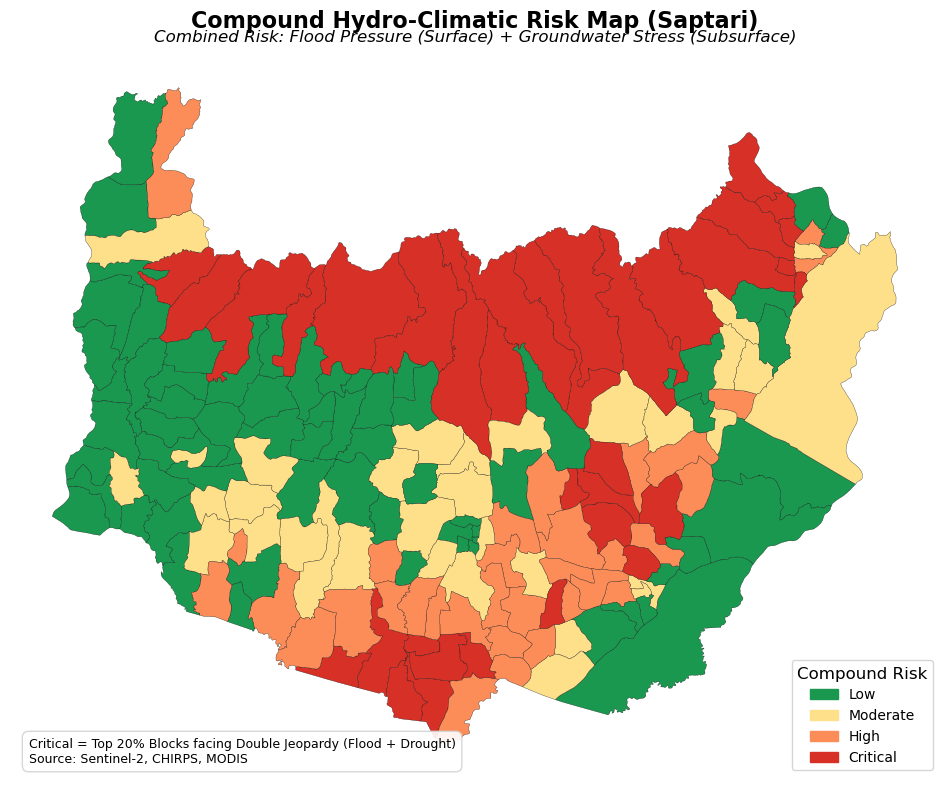

In [68]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- STEP 1: RELOAD THE CLEAN GEODATAFRAME (CRITICAL FIX) ---
# We reload from file to remove any duplicate columns from previous failed merges
block_gdf = gpd.read_file(r'S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\blocks_saptari_gee.geojson')
#block_gdf = gpd.read_file(r"D:\xward\data\boundaries\blocks_bihar_gee.geojson")
block_gdf["block_id"] = block_gdf["block_id"].astype(int)

# --- STEP 2: MERGE COMPOUND RISK DATA ---
# Ensure the risk_summary table is ready (from your previous step)
# If risk_summary is not defined, verify you ran the aggregation cell above.
risk_summary["block_uid"] = risk_summary["block_uid"].astype(int)

# Perform the merge
block_gdf = block_gdf.merge(
    risk_summary[["block_uid", "compound_risk", "compound_class"]],
    left_on="block_id",
    right_on="block_uid",
    how="left"
)

# --- STEP 3: PLOT THE FINAL MAP ---
# Define colors
risk_colors = {
    "Low": "#1a9850",       # Green
    "Moderate": "#fee08b",  # Yellow
    "High": "#fc8d59",      # Orange
    "Critical": "#d73027"   # Red
}

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot
block_gdf.plot(
    column="compound_class",
    categorical=True,
    color=block_gdf["compound_class"].map(risk_colors).fillna("lightgrey"),
    linewidth=0.2,
    edgecolor="black",
    ax=ax
)

# Custom Legend
legend_handles = [
    mpatches.Patch(color=risk_colors[cat], label=cat) 
    for cat in ["Low", "Moderate", "High", "Critical"] 
    if cat in block_gdf["compound_class"].unique()
]
ax.legend(
    handles=legend_handles, 
    loc="lower right", 
    title="Compound Risk",
    fontsize=10,
    title_fontsize=12
)

# Titles and Annotations
ax.set_title("Compound Hydro-Climatic Risk Map (Saptari)", fontsize=16, fontweight="bold", pad=20)
ax.text(
    0.5, 1.02, 
    "Combined Risk: Flood Pressure (Surface) + Groundwater Stress (Subsurface)", 
    transform=ax.transAxes, ha='center', fontsize=12, style='italic'
)
ax.text(
    0.02, 0.02, 
    "Critical = Top 20% Blocks facing Double Jeopardy (Flood + Drought)\nSource: Sentinel-2, CHIRPS, MODIS", 
    transform=ax.transAxes, fontsize=9, 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgrey', boxstyle='round,pad=0.5')
)

ax.axis("off")

# Save
output_path = "outputs/final_compound_risk_map_labeled.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✅ Map saved successfully to: {output_path}")
plt.show()

In [73]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare Time Series Data (Annual Mean per Block)
# We group by block and year to get the annual stress trend
trend_data = (
    df.groupby(["block_uid", "year"])["gw_stress_index"]
      .mean()
      .reset_index()
)

# 2. Define a function to calculate slope
def calculate_slope(group):
    # X = Year (reshaped for sklearn), y = Stress Index
    X = group["year"].values.reshape(-1, 1)
    y = group["gw_stress_index"].values
    
    # We need at least 2 years of data to calculate a trend
    if len(X) < 2:
        return np.nan
        
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0]  # The slope (coefficient)

# 3. Apply the function to every block (This might take 10-20 seconds)
print("Calculating trends for all blocks... please wait.")
block_slopes = (
    trend_data.groupby("block_uid")
              .apply(calculate_slope)
              .reset_index(name="stress_slope")
)

# 4. Classify the Trend
def classify_trend(slope):
    if slope > 2.0: return "Rapid Degradation"
    elif slope > 0.5: return "Worsening"
    elif slope < -0.5: return "Improving"
    else: return "Stable"

block_slopes["trend_status"] = block_slopes["stress_slope"].apply(classify_trend)

print("✅ Trends calculated successfully.")

Calculating trends for all blocks... please wait.
✅ Trends calculated successfully.


C:\Users\sujan\AppData\Local\Temp\ipykernel_28064\3540586425.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_slope)


In [74]:
print("Available columns:", block_gdf.columns.tolist())

Available columns: ['block_id', 'OBJECTID', 'block_name', 'geometry', 'block_uid', 'compound_risk', 'compound_class', 'GaPa_NaPa']


In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 1: FIX COLUMN NAMES ---

# 1. Rename 'block' to 'block_name' in the GeoDataFrame
block_gdf = block_gdf.rename(columns={"GaPa_NaPa": "block_name"})

# 2. Try to get District Names from the main DataFrame 'df'
# We check if 'dist_name' exists in df and merge it in
if "GaPa_NaPa" in df.columns:
    print("Found district names in main dataframe. Merging...")
    dist_map = df[["block_uid", "GaPa_NaPa"]].drop_duplicates().set_index("block_uid")["GaPa_NaPa"]
    block_gdf["GaPa_NaPa"] = block_gdf["block_id"].map(dist_map)
else:
    print("⚠️ Warning: 'GaPa_NaPa' not found in df. District Map might be skipped.")
    # Fallback: Create a dummy district column if needed or just skip
    block_gdf["GaPa_NaPa"] = "Unknown"

# --- STEP 2: GENERATE TOP 10 DEGRADING BLOCKS ---

# Merge trends (slopes) with the fixed names
# Note: Ensure 'block_slopes' exists from the Trend Analysis step. 
# If not, re-run the "Step 1: Calculate Trends" code from my previous response.
block_trends = block_gdf.merge(block_slopes, left_on="block_id", right_on="block_uid", how="left")

# Select columns to display
cols = ["block_name", "stress_slope", "trend_status"]
if "GaPa_NaPa" in block_trends.columns and block_trends["GaPa_NaPa"].iloc[0] != "Unknown":
    cols.insert(1, "GaPa_NaPa")

top_10_degrading = (
    block_trends.sort_values("stress_slope", ascending=False)
    [cols]
    .head(10)
)

print("\n🚨 TOP 10 FASTEST DEGRADING BLOCKS (2019-2024) 🚨")
print(top_10_degrading.to_string(index=False))
top_10_degrading.to_csv("outputs/top_10_degrading_blocks.csv", index=False)

# --- STEP 3: GENERATE DISTRICT MAP (If District Names Exist) ---

if block_gdf["GaPa_NaPa"].iloc[0] != "Unknown":
    # Aggregate to District
    district_trends = (
        block_trends.groupby("GaPa_NaPa")
        .agg({"stress_slope": "mean"})
        .rename(columns={"stress_slope": "avg_slope"})
        .reset_index()
    )

    # Dissolve Geometry
    district_gdf = block_gdf.dissolve(by="GaPa_NaPa", aggfunc="first").reset_index()
    district_gdf = district_gdf.merge(district_trends, on="GaPa_NaPa", how="left")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    district_gdf.plot(
        column="avg_slope", cmap="Reds", legend=True,
        legend_kwds={'label': "Avg Degradation Rate (Slope)"},
        edgecolor="black", linewidth=0.5, ax=ax
    )
    
    # Label top 5 districts
    top_5 = district_gdf.sort_values("avg_slope", ascending=False).head(5)
    for idx, row in top_5.iterrows():
        plt.annotate(
            text=row["GaPa_NaPa"], 
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            xytext=(0, 0), textcoords="offset points",
            fontsize=8, fontweight='bold', ha='center'
        )

    ax.set_title("District-Level Groundwater Degradation Trends")
    ax.axis("off")
    plt.savefig("outputs/district_degradation_map.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("\n⚠️ Skipping District Map because district names are missing.")
    print("Action: Check your original CSV file to see if it has a 'District' column.")

⚠️ Warning: 'GaPa_NaPa' not found in df. District Map might be skipped.

🚨 TOP 10 FASTEST DEGRADING BLOCKS (2019-2024) 🚨
            block_name block_name  stress_slope      trend_status
Hanumannagar Kankalini    Unknown      2.928432 Rapid Degradation
          Chhinnamasta    Unknown      2.910244 Rapid Degradation
       Tilathi Koiladi    Unknown      2.835914 Rapid Degradation
          Chhinnamasta    Unknown      2.813555 Rapid Degradation
       Tilathi Koiladi    Unknown      2.809896 Rapid Degradation
Hanumannagar Kankalini    Unknown      2.768141 Rapid Degradation
       Tilathi Koiladi    Unknown      2.743860 Rapid Degradation
         Belhi Chapena    Unknown      2.742574 Rapid Degradation
Hanumannagar Kankalini    Unknown      2.738913 Rapid Degradation
              Mahadeva    Unknown      2.731421 Rapid Degradation

⚠️ Skipping District Map because district names are missing.
Action: Check your original CSV file to see if it has a 'District' column.


C:\Users\sujan\AppData\Local\Temp\ipykernel_28064\2567031336.py:32: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  block_gdf.plot(


✅ Trend Map saved to: outputs/final_trend_map.png


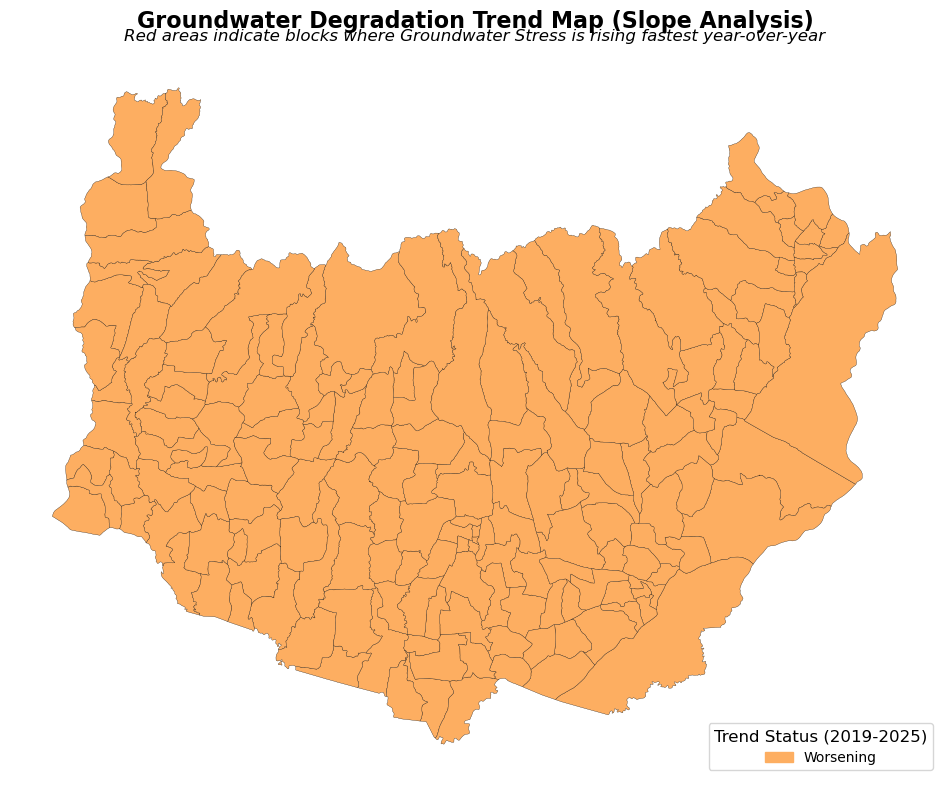

In [77]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- STEP 1: PREPARE TREND DATA ---
# Ensure 'block_slopes' is ready (from the Trend Analysis step)
# Merge it into the GeoDataFrame if not already there
if "stress_slope" not in block_gdf.columns:
    block_gdf = block_gdf.merge(block_slopes, left_on="block_id", right_on="block_uid", how="left")

# --- STEP 2: CLASSIFY TRENDS ---
# We categorize the slope (rate of change) into actionable classes
def classify_trend_visual(slope):
    if slope < -0.5: return "Improving"        # Negative slope = Stress reducing
    elif slope < 0.5: return "Stable"          # Near zero = No major change
    elif slope < 5.0: return "Worsening"       # Positive = Stress increasing
    else: return "Rapid Degradation"           # High Positive = Critical failure

block_gdf["trend_class"] = block_gdf["stress_slope"].apply(classify_trend_visual)

# --- STEP 3: PLOT THE TREND MAP ---

# Define Colors: Blue (Good) -> Yellow (Neutral) -> Red (Bad)
trend_colors = {
    "Improving": "#2c7bb6",         # Blue
    "Stable": "#ffffbf",            # Pale Yellow
    "Worsening": "#fdae61",         # Orange
    "Rapid Degradation": "#d7191c"  # Dark Red
}

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

block_gdf.plot(
    column="trend_class",
    categorical=True,
    legend=True,
    color=block_gdf["trend_class"].map(trend_colors).fillna("lightgrey"),
    linewidth=0.2,
    edgecolor="black",
    ax=ax
)

# --- STEP 4: ADD PROFESSIONAL LEGEND & LABELS ---

# Custom Legend
legend_handles = [
    mpatches.Patch(color=trend_colors[cat], label=cat) 
    for cat in ["Improving", "Stable", "Worsening", "Rapid Degradation"] 
    if cat in block_gdf["trend_class"].unique()
]

ax.legend(
    handles=legend_handles, 
    loc="lower right", 
    title="Trend Status (2019-2025)",
    fontsize=10,
    title_fontsize=12,
    frameon=True
)

# Title
ax.set_title(
    "Groundwater Degradation Trend Map (Slope Analysis)", 
    fontsize=16, 
    fontweight="bold",
    pad=20
)

# Annotation
ax.text(
    0.5, 1.02, 
    "Red areas indicate blocks where Groundwater Stress is rising fastest year-over-year", 
    transform=ax.transAxes, ha='center', fontsize=12, style='italic'
)

# Remove Axis
ax.axis("off")

# Save
output_path = "outputs/final_trend_map.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✅ Trend Map saved to: {output_path}")
plt.show()

In [78]:
import geopandas as gpd

# 1. Select the most important columns for the final output
# We check which columns actually exist to avoid errors
target_columns = [
    "block_id", "block_name", "GaPa_NaPa",    # Identifiers
    "flood_pressure", "gw_stress_index",      # Raw Metrics
    "compound_risk", "compound_class",        # Flagship Index
    "stress_slope", "trend_class",            # Trend Analysis
    "geometry"                                # Map Shape
]

# Filter only columns that exist in your current block_gdf
final_cols = [c for c in target_columns if c in block_gdf.columns]

# 2. Create the Final GeoDataFrame
final_export_gdf = block_gdf[final_cols].copy()

# 3. Rename columns for GIS friendliness (Optional, makes them look cleaner in QGIS)
# e.g., "gw_stress_index" -> "GW_Stress"
rename_map = {
    "flood_pressure": "Flood_Risk_Score",
    "gw_stress_index": "GW_Stress_Score",
    "compound_risk": "Compound_Score",
    "compound_class": "Risk_Category",
    "stress_slope": "Degradation_Rate",
    "trend_class": "Trend_Status"
}
final_export_gdf = final_export_gdf.rename(columns=rename_map)

In [79]:
final_export_gdf.drop(['block_name'],axis=1)

,block_id,GaPa_NaPa,Compound_Score,Risk_Category,Degradation_Rate,Trend_Status,geometry
0,0,Unknown,0.499073,Low,1.540210,Worsening,"POLYGON ((453671.231 2946370.985, 453686.356 2..."
1,1,Unknown,0.510860,Low,2.278113,Worsening,"POLYGON ((463246.049 2934288.208, 463254.109 2..."
2,2,Unknown,0.499553,Low,2.109118,Worsening,"POLYGON ((468868.839 2939991.04, 468914.676 29..."
3,3,Unknown,0.563465,Critical,2.597939,Worsening,"POLYGON ((469313.301 2932125.406, 469319.458 2..."
4,4,Unknown,0.551085,High,2.425325,Worsening,"POLYGON ((477973.98 2935513.956, 478056.124 29..."
...,...,...,...,...,...,...,...
160,160,Unknown,0.515762,Moderate,1.967361,Worsening,"POLYGON ((462114.544 2941473.233, 462300.197 2..."
161,161,Unknown,0.555540,High,2.389117,Worsening,"POLYGON ((479899.175 2934036.256, 480058.557 2..."
162,162,Unknown,0.555885,High,2.636743,Worsening,"POLYGON ((483028.05 2933309.157, 483090.351 29..."
163,163,Unknown,0.521984,Moderate,2.290703,Worsening,"POLYGON ((473242.424 2935154.779, 473318.324 2..."


In [80]:
final_export_gdf.columns

Index(['block_id', 'block_name', 'block_name', 'GaPa_NaPa', 'Compound_Score',
       'Risk_Category', 'Degradation_Rate', 'Trend_Status', 'geometry'],
      dtype='object')

In [81]:
# 4. Export to GeoJSON (Best for Web/Python/QGIS)
output_file = "outputs/final_risk_atlas_saptari.geojson"
final_export_gdf.drop(columns="block_name").to_file(output_file, driver="GeoJSON")

# 5. Export to CSV (Best for Excel/Reports - drops geometry)
output_csv = "outputs/final_risk_atlas_table.csv"
final_export_gdf.drop(columns="geometry").to_csv(output_csv, index=False)

print(f"✅ SUCCESS! Final Atlas exported to:")
print(f"   - Map File: {output_file}")
print(f"   - Table File: {output_csv}")
print("\nYou can now drag 'final_risk_atlas_saptari.geojson' directly into QGIS or Google Earth.")

✅ SUCCESS! Final Atlas exported to:
   - Map File: outputs/final_risk_atlas_saptari.geojson
   - Table File: outputs/final_risk_atlas_table.csv

You can now drag 'final_risk_atlas_saptari.geojson' directly into QGIS or Google Earth.


In [82]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import os

print("🔄 Starting Complete Data Recovery...")

# --- 1. LOAD BOUNDARIES ---
# Robust path check
possible_paths = [
    r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\blocks_saptari_gee.geojson"#,
    #r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\blocks_saptari.geojson"
]

block_gdf = None
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ Found boundaries at: {path}")
        block_gdf = gpd.read_file(path)
        break

if block_gdf is None:
    raise FileNotFoundError("Could not find 'blocks_saptari_gee.geojson'. Check your paths.")

block_gdf["block_id"] = block_gdf["block_id"].astype(int)

# --- 2. AGGREGATE SCORES (Flood & GW) ---
print("📊 Aggregating Flood & Groundwater Scores...")
scores_df = df.groupby("block_uid", as_index=False).agg({
    "flood_pressure": "mean",
    "gw_stress_index": "mean"
})
scores_df["block_uid"] = scores_df["block_uid"].astype(int)

# --- 3. RE-CALCULATE TRENDS (The missing part) ---
print("📈 Re-calculating Trends...")
# Create annual average for trend analysis
annual_df = df.groupby(["block_uid", "year"])["gw_stress_index"].mean().reset_index()

def calc_slope(group):
    if len(group) < 2: return 0.0
    model = LinearRegression()
    model.fit(group[["year"]], group["gw_stress_index"])
    return model.coef_[0]

# Calculate slope per block
trend_df = annual_df.groupby("block_uid").apply(
    lambda x: calc_slope(x)
).reset_index(name="stress_slope")

# Classify Trend
def classify_trend(slope):
    if slope > 2.0: return "Rapid Degradation"
    elif slope > 0.5: return "Worsening"
    elif slope < -0.5: return "Improving"
    else: return "Stable"

trend_df["trend_class"] = trend_df["stress_slope"].apply(classify_trend)
trend_df["block_uid"] = trend_df["block_uid"].astype(int)

# --- 4. MERGE EVERYTHING ---
print("🔗 Merging all data...")
# Merge Scores
merged_gdf = block_gdf.merge(scores_df, left_on="block_id", right_on="block_uid", how="left")
# Merge Trends
merged_gdf = merged_gdf.merge(trend_df, left_on="block_id", right_on="block_uid", how="left")

# --- 5. CALCULATE COMPOUND RISK ---
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

merged_gdf["Flood_Norm"] = normalize(merged_gdf["flood_pressure"])
merged_gdf["GW_Norm"] = normalize(merged_gdf["gw_stress_index"])
merged_gdf["Compound_Score"] = 0.5 * merged_gdf["Flood_Norm"] + 0.5 * merged_gdf["GW_Norm"]

q80 = merged_gdf["Compound_Score"].quantile(0.80)
merged_gdf["Risk_Category"] = merged_gdf["Compound_Score"].apply(lambda x: "Critical" if x > q80 else "Normal")

# --- 6. RENAME & EXPORT ---
final_gdf = merged_gdf.rename(columns={
    "flood_pressure": "Flood_Risk_Score",
    "gw_stress_index": "GW_Stress_Score",
    "stress_slope": "Degradation_Rate",
    "trend_class": "Trend_Status",
    "block": "block_name",
    "dist": "dist_name"
})

# Save to the folder the App uses
output_path = r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\final_risk_atlas_saptari.geojson"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_gdf.to_file(output_path, driver="GeoJSON")

print(f"✅ SUCCESS! Final Atlas saved to: {output_path}")
print("👉 Now restart your Streamlit App.")

🔄 Starting Complete Data Recovery...
✅ Found boundaries at: S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\blocks_saptari_gee.geojson
📊 Aggregating Flood & Groundwater Scores...
📈 Re-calculating Trends...


C:\Users\sujan\AppData\Local\Temp\ipykernel_28064\2096915272.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_df = annual_df.groupby("block_uid").apply(


🔗 Merging all data...
✅ SUCCESS! Final Atlas saved to: S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\final_risk_atlas_saptari.geojson
👉 Now restart your Streamlit App.


In [99]:
# Checking the final file

In [83]:
file = r"S:\Tutorial\region-risk-atlas\regoin-risk-atlas\data\final_risk_atlas_saptari.geojson"
gdf = gpd.read_file(file)
gdf.head(5)

,block_id,OBJECTID,GaPa_NaPa,block_uid_x,Flood_Risk_Score,GW_Stress_Score,block_uid_y,Degradation_Rate,Trend_Status,Flood_Norm,GW_Norm,Compound_Score,Risk_Category,geometry
0,0,4341,Surunga,0,148.227961,-27.737391,0,1.540210,Worsening,0.092443,0.905702,0.499073,Normal,"POLYGON ((453671.231 2946370.985, 453686.356 2..."
1,1,4342,Dakneshwori,1,152.540513,-28.352568,1,2.278113,Rapid Degradation,0.182697,0.839022,0.510860,Normal,"POLYGON ((463246.049 2934288.208, 463254.109 2..."
2,2,4343,Dakneshwori,2,161.204214,-30.233993,2,2.109118,Rapid Degradation,0.364012,0.635094,0.499553,Normal,"POLYGON ((468868.839 2939991.04, 468914.676 29..."
3,3,4344,Belhi Chapena,3,163.700041,-29.536598,3,2.597939,Rapid Degradation,0.416245,0.710685,0.563465,Critical,"POLYGON ((469313.301 2932125.406, 469319.458 2..."
4,4,4345,Rajbiraj,4,159.733785,-28.999216,4,2.425325,Rapid Degradation,0.333239,0.768932,0.551085,Normal,"POLYGON ((477973.98 2935513.956, 478056.124 29..."


In [84]:
gdf.columns

Index(['block_id', 'OBJECTID', 'GaPa_NaPa', 'block_uid_x', 'Flood_Risk_Score',
       'GW_Stress_Score', 'block_uid_y', 'Degradation_Rate', 'Trend_Status',
       'Flood_Norm', 'GW_Norm', 'Compound_Score', 'Risk_Category', 'geometry'],
      dtype='object')